In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
# Load CSV dataset
data = pd.read_csv("Injury_Prediction_Dataset_2000_Clean.csv")

print("Dataset Loaded Successfully")
print(data.head())



Dataset Loaded Successfully
             Name  Gender  Location Sport_Category PlayerID  Age  \
0   Krishna Mehta    Male  Vadodara       Swimming    P0001   22   
1    Vivaan Desai    Male     Kochi         Tennis    P0002   21   
2   Pooja Agarwal  Female     Thane        Cricket    P0003   24   
3  Siddharth Iyer    Male    Indore   Table Tennis    P0004   20   
4    Charvi Sinha  Female    Indore     Basketball    P0005   20   

   TrainingLoad  ACWR  HRV  PreviousInjury  SleepHours  FatigueScore  \
0           525  1.72   78               0           7             5   
1           407  1.12   86               1           4             8   
2           599  1.87   56               1           8            10   
3           427  0.90   56               1           6             5   
4           850  1.55   57               0           7             8   

   InjuryRisk  
0           0  
1           1  
2           1  
3           0  
4           1  


In [10]:
X = data[[
    "Age",
    "TrainingLoad",
    "ACWR",
    "HRV",
    "PreviousInjury",
    "SleepHours",
    "FatigueScore"
]]

y = data["InjuryRisk"]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [12]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [13]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Model Accuracy: 0.99

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       237
           1       0.98      0.99      0.99       163

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400


Confusion Matrix:
[[234   3]
 [  1 162]]


In [17]:
with open("injury_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("\nModel Saved as injury_model.pkl")



Model Saved as injury_model.pkl


In [21]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.99


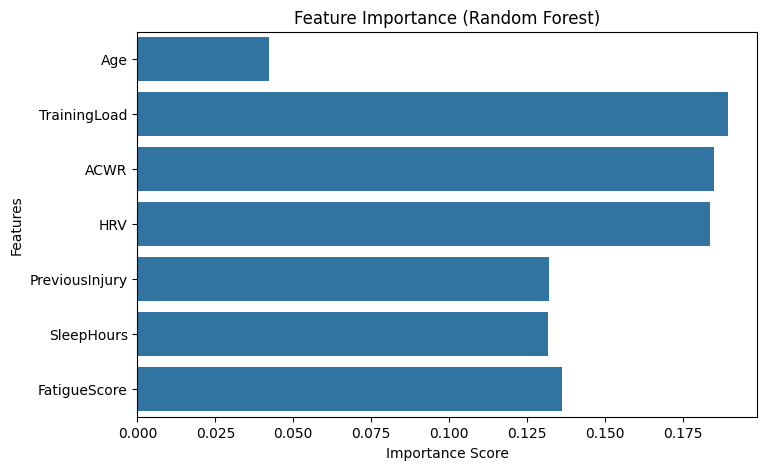

In [23]:
importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

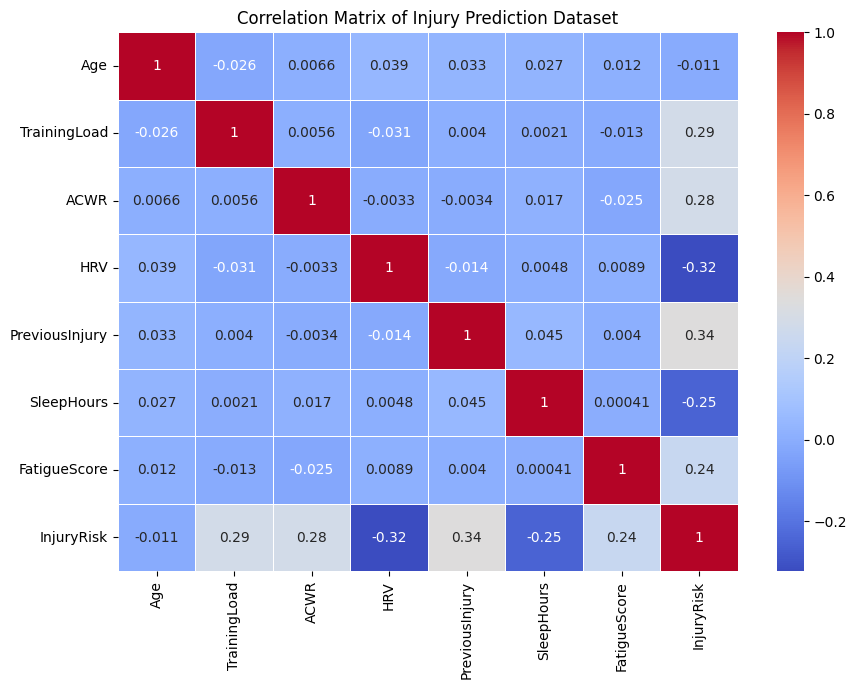

In [24]:


# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Matrix of Injury Prediction Dataset")
plt.show()